In [15]:
import pandas as pd

mRNA_df = pd.read_csv('Pan-cancer_mRNA.csv', index_col=0)
Methy_df = pd.read_csv('Pan-cancer_Methy.csv', index_col=0)
Clinical_df = pd.read_csv('Clinical_Rec.csv', index_col=0)
mRNA_df = mRNA_df.T
Methy_df = Methy_df.T

print("mRNA shape:", mRNA_df.shape)
print("Methy shape:", Methy_df.shape)
print("Clinical shape:", Clinical_df.shape)


mRNA shape: (8314, 3217)
Methy shape: (8314, 3139)
Clinical shape: (8314, 6)


In [17]:
# Load clinical data with 'sample' as index
Clinical_df = pd.read_csv('Clinical_Rec.csv', index_col=0)

print("Clinical columns:", Clinical_df.columns)
print("Clinical index (sample IDs):", Clinical_df.index[:5])


Clinical columns: Index(['status', 'days', 'age_at_initial_pathologic_diagnosis', 'gender',
       'pathologic_stage', 'label'],
      dtype='object')
Clinical index (sample IDs): Index(['TCGA-05-4384-01', 'TCGA-05-4390-01', 'TCGA-05-4396-01',
       'TCGA-05-4405-01', 'TCGA-05-4410-01'],
      dtype='object', name='sample')


In [18]:
# Normalize IDs to be safe
mRNA_df.index = mRNA_df.index.astype(str).str.upper()
Methy_df.index = Methy_df.index.astype(str).str.upper()
Clinical_df.index = Clinical_df.index.astype(str).str.upper()

# Find common samples
common_ids = list(set(mRNA_df.index) & set(Methy_df.index) & set(Clinical_df.index))
print("Number of common samples:", len(common_ids))

# Subset dataframes
mRNA_df = mRNA_df.loc[common_ids]
Methy_df = Methy_df.loc[common_ids]
Clinical_df = Clinical_df.loc[common_ids]

print("Aligned shapes:")
print("mRNA:", mRNA_df.shape)
print("Methy:", Methy_df.shape)
print("Clinical:", Clinical_df.shape)


Number of common samples: 8314
Aligned shapes:
mRNA: (8314, 3217)
Methy: (8314, 3139)
Clinical: (8314, 6)


#Summary Stats

In [20]:
# Percentage of missing values per modality
print("mRNA missing values (%):")
print(mRNA_df.isnull().mean().head())

print("\nMethy missing values (%):")
print(Methy_df.isnull().mean().head())

print("\nClinical missing values (%):")
print(Clinical_df.isnull().mean())


mRNA missing values (%):
sample
KRT5       0.0
KRT6A      0.0
CEACAM5    0.0
KRT14      0.0
RPS4Y1     0.0
dtype: float64

Methy missing values (%):
sample
cg00211215    0.0
cg00123762    0.0
cg00092518    0.0
cg00011616    0.0
cg00177787    0.0
dtype: float64

Clinical missing values (%):
status                                 0.000842
days                                   0.006375
age_at_initial_pathologic_diagnosis    0.005894
gender                                 0.000000
pathologic_stage                       0.000000
label                                  0.000000
dtype: float64


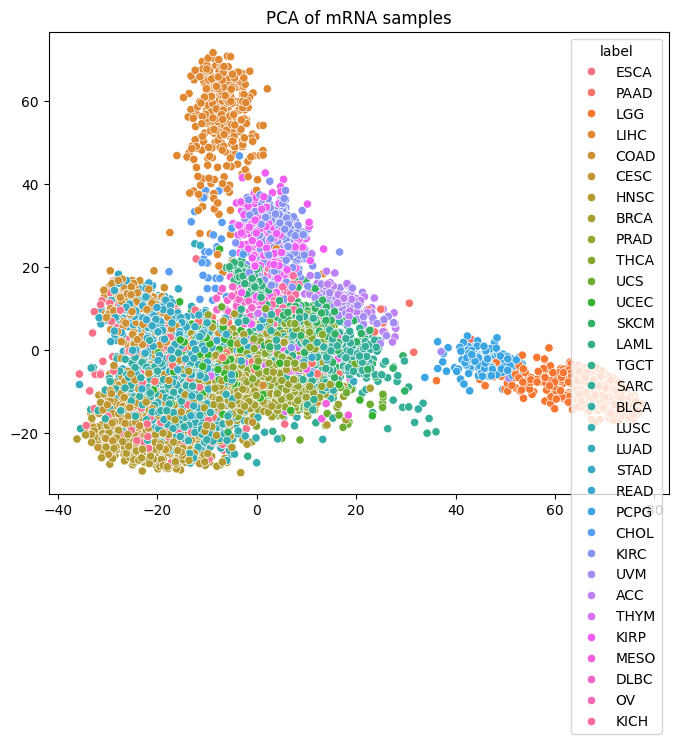

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Example: PCA on mRNA
pca = PCA(n_components=2)
mRNA_pca = pca.fit_transform(mRNA_df.fillna(0))  # fill NaNs with 0 or mean

plt.figure(figsize=(8,6))
sns.scatterplot(x=mRNA_pca[:,0], y=mRNA_pca[:,1], hue=Clinical_df['label'])
plt.title('PCA of mRNA samples')
plt.show()

#Counterplot for Labels

/tmp/ipython-input-1733314268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=Clinical_df, palette='viridis')


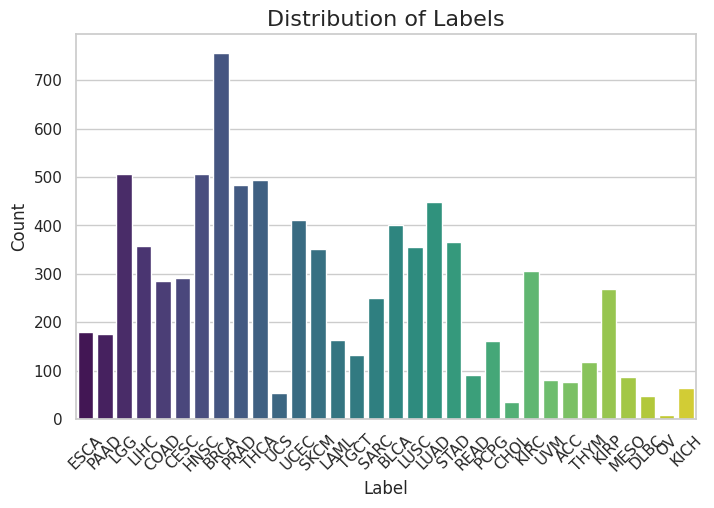

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# Plot label distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=Clinical_df, palette='viridis')
plt.title('Distribution of Labels', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()


#Research Questions


Primary RQs (final model / clustering):

RQ1 – Multi-Omics Integration Across Cancers:
Can mRNA, DNA methylation, and clinical data be integrated to distinguish between different cancer types in a Pan-Cancer cohort?

RQ2 – Early Fusion Effectiveness:
Does a unified tokenization and early-fusion transformer improve separation of cancer types compared to baseline PCA + K-Means clustering?

RQ3 – Clinical Relevance:
Are clusters associated with known cancer types or clinical outcomes such as survival or stage?

RQ4 – Feature Contribution:
Which molecular and clinical features drive the separation of cancer types?

EDA-Based Questions:

RQ5: Distribution of cancer types and labels

RQ6: Variability of molecular features across cancers

RQ7: Patterns of missing data across the Pan-Cancer modalities

#Baseline Model

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
# Load CSVs
mRNA_df = pd.read_csv('Pan-cancer_mRNA.csv', index_col=0).T
Methy_df = pd.read_csv('Pan-cancer_Methy.csv', index_col=0).T
Clinical_df = pd.read_csv('Clinical_Rec.csv', index_col=0)

# Normalize sample IDs
def normalize_ids(df):
    df.index = df.index.astype(str).str.upper().str.strip()
    return df

mRNA_df = normalize_ids(mRNA_df)
Methy_df = normalize_ids(Methy_df)
Clinical_df = normalize_ids(Clinical_df)

# Align samples across modalities
common_ids = list(set(mRNA_df.index) & set(Methy_df.index) & set(Clinical_df.index))
mRNA_df = mRNA_df.loc[common_ids]
Methy_df = Methy_df.loc[common_ids]
Clinical_df = Clinical_df.loc[common_ids]

print("Aligned shapes:")
print("mRNA:", mRNA_df.shape)
print("Methy:", Methy_df.shape)
print("Clinical:", Clinical_df.shape)


Aligned shapes:
mRNA: (8314, 3217)
Methy: (8314, 3139)
Clinical: (8314, 6)


In [38]:
from sklearn.impute import SimpleImputer

scaler = StandardScaler()
mRNA_scaled = scaler.fit_transform(mRNA_df.fillna(0)) # fill NaNs with 0 before scaling
Methy_scaled = scaler.fit_transform(Methy_df.fillna(0)) # fill NaNs with 0 before scaling

# Impute any remaining NaNs after scaling (shouldn't be any with fillna(0) but as a safeguard)
imputer = SimpleImputer(strategy='mean')
mRNA_scaled_imputed = imputer.fit_transform(mRNA_scaled)
Methy_scaled_imputed = imputer.fit_transform(Methy_scaled)

In [32]:
# One-hot encode categorical features like gender or pathologic_stage
categorical_cols = ['gender', 'pathologic_stage']
ohe = OneHotEncoder(handle_unknown='ignore')
clinical_cat = ohe.fit_transform(Clinical_df[categorical_cols]).toarray()

# Numerical features
numerical_cols = ['age_at_initial_pathologic_diagnosis', 'days']
clinical_num_df = Clinical_df[numerical_cols]
# Impute missing values in numerical clinical features with the mean
clinical_num_imputed = clinical_num_df.fillna(clinical_num_df.mean()).values

# Concatenate clinical features
clinical_processed = np.hstack([clinical_num_imputed, clinical_cat])

#Early Fusion

In [39]:
X = np.hstack([mRNA_scaled_imputed, Methy_scaled_imputed, clinical_processed])
print("Combined feature matrix shape:", X.shape)

Combined feature matrix shape: (8314, 6364)


In [40]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)
print("PCA-reduced shape:", X_pca.shape)


PCA-reduced shape: (8314, 50)


In [41]:
kmeans = KMeans(n_clusters=5, random_state=42)  # choose n_clusters based on prior knowledge
clusters = kmeans.fit_predict(X_pca)

# Evaluate
sil_score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", sil_score)

# Add clusters to Clinical_df for visualization
Clinical_df['cluster'] = clusters


Silhouette Score: 0.5348352107364239


/tmp/ipython-input-3568476889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=Clinical_df, palette='viridis')


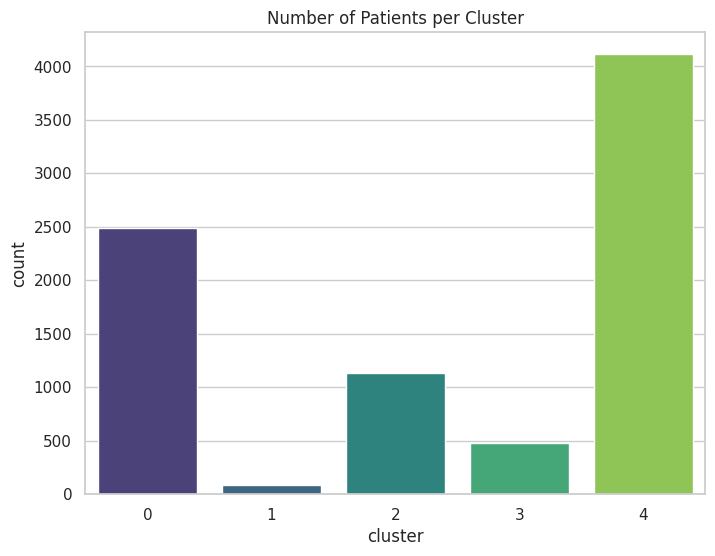

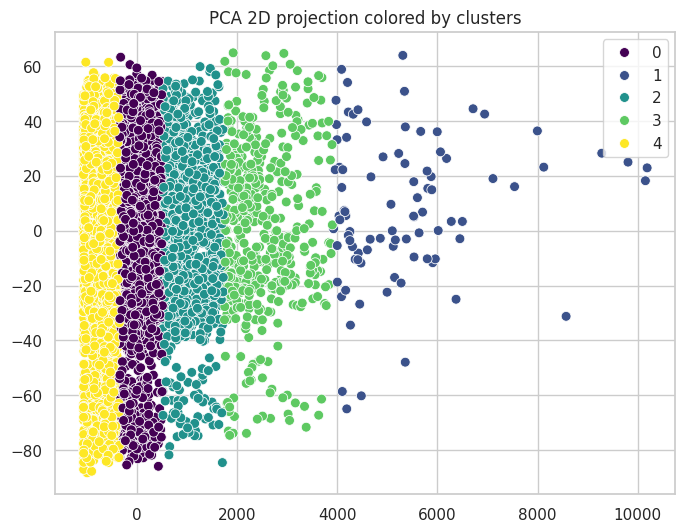

In [42]:
plt.figure(figsize=(8,6))
sns.countplot(x='cluster', data=Clinical_df, palette='viridis')
plt.title('Number of Patients per Cluster')
plt.show()

# Optional: PCA 2D scatter
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='viridis', s=50)
plt.title('PCA 2D projection colored by clusters')
plt.show()


In [43]:
print(Clinical_df.groupby('cluster')['label'].value_counts())
print(Clinical_df.groupby('cluster')[['age_at_initial_pathologic_diagnosis']].mean())


cluster  label
0        BRCA     217
         PRAD     203
         THCA     192
         LGG      168
         HNSC     154
                 ... 
4        CHOL      21
         ACC       19
         DLBC      18
         KICH       9
         OV         6
Name: count, Length: 139, dtype: int64
         age_at_initial_pathologic_diagnosis
cluster                                     
0                                  57.575893
1                                  44.100000
2                                  57.146797
3                                  54.374737
4                                  60.249270


#Experiment Logging

| Experiment            | RQ Addressed  | Method                       | Outcome        | Notes / Next Step                             |
| --------------------- | ------------- | ---------------------------- | -------------- | --------------------------------------------- |
| PCA + KMeans          | RQ1, RQ3      | Early-fusion of mRNA + Methy | Silhouette TBD | Baseline, evaluate separation of cancer types |
| Top 5000 features     | RQ1, RQ2      | Feature selection            | TBD            | Check if fewer features improve clustering    |
| Transformer embedding | RQ1, RQ2, RQ4 | Unified tokenization         | TBD            | Final model to compare with baseline          |
